# 06 LOF Validation

这一份 notebook 用来回答：

> **除了 Isolation Forest 之外，另一种无监督方法是否也支持主异常窗口的存在？**

这里使用 **LOF（Local Outlier Factor）** 作为对比方法。

目标：
1. 读取并清洗原始数据
2. 使用 LOF 进行无监督异常检测
3. 生成 `lof_label` 和 `lof_score`
4. 查看 LOF 最异常样本
5. 画 LOF 全局/局部曲线
6. 判断 LOF 是否也支持 `12115~12135` 主异常窗口


## 0. 导入库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1800)


## 1. 读取并清洗数据

沿用前面已经确认过的清洗逻辑：
- `Flow2` 先转字符串
- 去掉两边空格
- 把逗号改成点
- 再转成数值型

In [2]:
df = pd.read_csv('../data/PWR Abnormality Dataset.csv')

df['Flow2'] = df['Flow2'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Flow2'] = pd.to_numeric(df['Flow2'], errors='coerce')

df_clean = df.copy()
df_model = df.drop(columns=['Readings'])

print('原始数据形状：', df.shape)
print('建模数据形状：', df_model.shape)
print('Flow2 缺失值数量：', df['Flow2'].isna().sum())
df.head()

原始数据形状： (12267, 17)
建模数据形状： (12267, 16)
Flow2 缺失值数量： 0


,Readings,Temperature,Pressure,Flow1,Flow2,VRR12,VRR22,VRR23,VRR33,VRS01,VRS03,VRS21,VRS31,VRS02,VRI01,VRI02,VRI03
0,1,248.852987,9.689813,4462.130014,13302.92650,19.060938,0.059119,0.050589,0.111864,0.033951,0.047812,0.232627,0.253775,0.400726,1.763223,0.003031,0.004995
1,2,269.315740,1.279532,4480.252595,13784.45225,19.062128,0.059089,0.048788,0.111340,0.034060,0.052611,0.233342,0.315067,0.128517,1.769272,0.003164,0.004999
2,3,94.320644,6.280686,4325.270376,12899.98773,19.061641,0.058145,0.048552,0.111118,0.033859,0.053999,0.233387,0.380191,0.321816,1.768585,0.003321,0.004996
3,4,271.019823,0.669886,4481.761795,13733.00610,19.062453,0.058236,0.049514,0.112658,0.034049,0.050767,0.233850,0.329846,0.132092,1.772432,0.003061,0.004998
4,5,207.876262,6.806043,4425.839490,13500.22222,19.061101,0.058378,0.049809,0.111252,0.033996,0.052669,0.233619,0.390729,0.247973,1.772356,0.003060,0.004994


## 2. 标准化

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print('标准化后数据形状：', X_scaled.shape)

标准化后数据形状： (12267, 16)


## 3. 训练 LOF

这里使用：
- `n_neighbors=20`
- `contamination=0.05`

注意：
- `lof_label = 1` 表示正常
- `lof_label = -1` 表示异常
- `negative_outlier_factor_` 越小，表示越异常

In [4]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred = lof.fit_predict(X_scaled)

df_clean['lof_label'] = pred
df_clean['lof_score'] = lof.negative_outlier_factor_

print('LOF 异常检测结果统计：')
print(df_clean['lof_label'].value_counts())

LOF 异常检测结果统计：
lof_label
 1    11653
-1      614
Name: count, dtype: int64


## 4. 查看 LOF 最异常样本

这里重点看：
- 最异常样本是否集中在 `12115~12135`
- 是否同时存在其他类型的孤立异常点

In [5]:
top10_lof = df_clean.sort_values(by='lof_score', ascending=True).head(10)

print('LOF 最异常的10个样本：')
display(top10_lof[['Readings', 'Temperature', 'Pressure', 'Flow1', 'Flow2', 'lof_label', 'lof_score']])

LOF 最异常的10个样本：


,Readings,Temperature,Pressure,Flow1,Flow2,lof_label,lof_score
12180,12181,66.21507,0.240286,4395.408109,13156.70546,-1,-2.571817
12226,12227,179.08680,3.090756,4474.167019,13874.59098,-1,-2.447558
12231,12232,197.46900,4.207460,4315.301641,13801.93536,-1,-2.311850
12147,12148,287.49960,16.564930,4406.083433,14079.29604,-1,-1.755957
12000,12001,122.36720,16.204470,4319.400000,12958.30000,-1,-1.497083
12138,12139,287.94680,15.869240,4330.921329,13671.33230,-1,-1.465889
12131,12132,287.66510,16.000170,4412.651254,13402.11830,-1,-1.465728
12009,12010,118.26200,15.620800,4436.790155,14753.17300,-1,-1.452477
12137,12138,287.22860,15.955950,4341.196448,13633.56599,-1,-1.407500
12141,12142,288.27110,15.837830,4412.429245,13590.47690,-1,-1.405231


## 5. LOF 全局分数图

这张图用于看：
- 是否存在明显的异常区段
- 是否还会同时出现若干孤立的异常尖刺

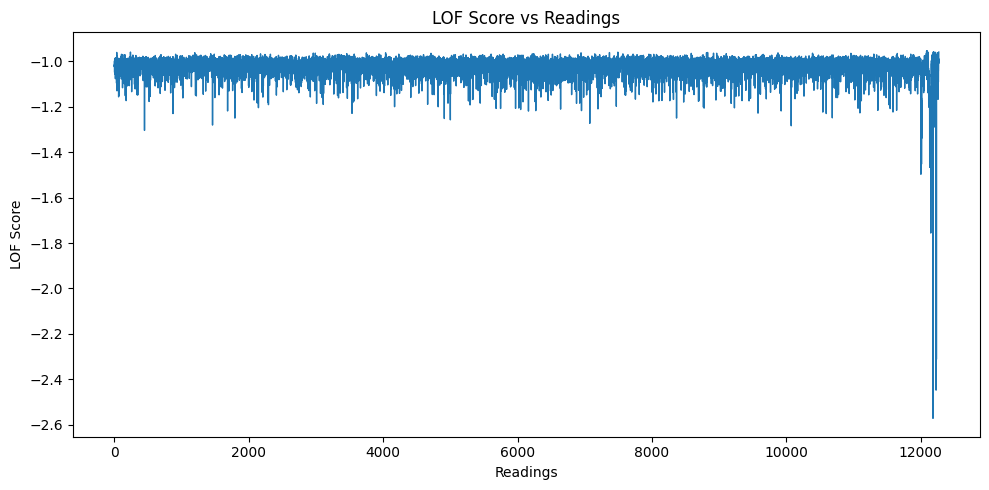

图片已保存到 ../outputs/figures/lof_score_all.png


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df_clean['Readings'], df_clean['lof_score'], linewidth=1)
plt.xlabel('Readings')
plt.ylabel('LOF Score')
plt.title('LOF Score vs Readings')
plt.tight_layout()
plt.savefig('../outputs/figures/lof_score_all.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/lof_score_all.png')

## 6. LOF 局部放大图

这里放大 `12050~12267` 区间，观察末端异常窗口是否依然存在。

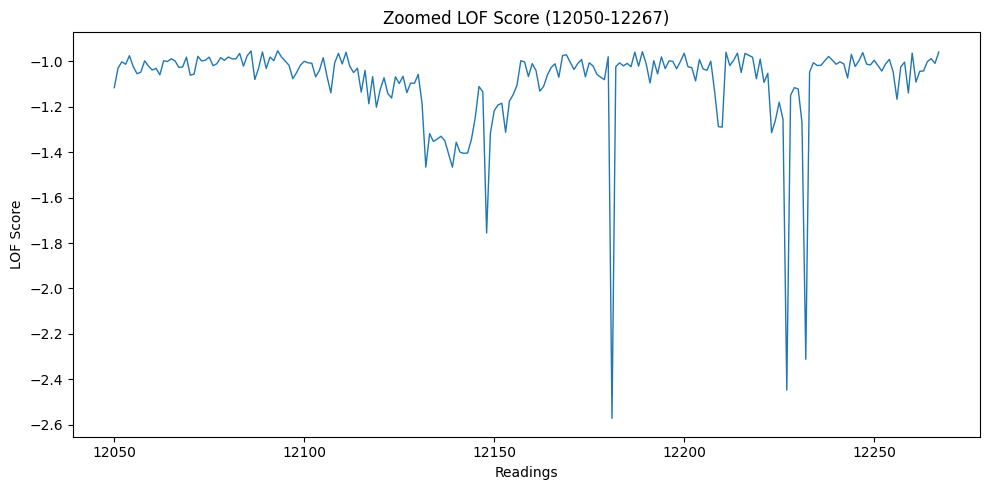

图片已保存到 ../outputs/figures/lof_score_zoom.png


In [7]:
zoom_df = df_clean[(df_clean['Readings'] >= 12050) & (df_clean['Readings'] <= 12267)].copy()

plt.figure(figsize=(10, 5))
plt.plot(zoom_df['Readings'], zoom_df['lof_score'], linewidth=1)
plt.xlabel('Readings')
plt.ylabel('LOF Score')
plt.title('Zoomed LOF Score (12050-12267)')
plt.tight_layout()
plt.savefig('../outputs/figures/lof_score_zoom.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/lof_score_zoom.png')

## 7. 统计主异常窗口命中情况

这里重点回答：
- `12115~12135` 这个窗口里有多少点被 LOF 判成异常
- top10 里有多少点落在这个窗口内

In [8]:
window_start = 12115
window_end = 12135

window_df = df_clean[(df_clean['Readings'] >= window_start) & (df_clean['Readings'] <= window_end)].copy()
window_anomaly_count = (window_df['lof_label'] == -1).sum()
window_size = len(window_df)
window_ratio = window_anomaly_count / window_size

top10_hit_count = ((top10_lof['Readings'] >= window_start) & (top10_lof['Readings'] <= window_end)).sum()

print('主异常窗口样本数：', window_size)
print('主异常窗口中被 LOF 判成异常的数量：', window_anomaly_count)
print('主异常窗口异常比例：', window_ratio)
print('LOF top10 中落在主异常窗口内的样本数：', top10_hit_count)

主异常窗口样本数： 21
主异常窗口中被 LOF 判成异常的数量： 15
主异常窗口异常比例： 0.7142857142857143
LOF top10 中落在主异常窗口内的样本数： 1


## 8. 保存 LOF 结果表

In [9]:
save_path = '../outputs/tables/pwr_lof_with_scores.csv'
df_clean.to_csv(save_path, index=False)
print(f'结果表已保存到 {save_path}')

结果表已保存到 ../outputs/tables/pwr_lof_with_scores.csv


## 9. 结论


1. LOF 的局部曲线中，末端异常区依然明显
2. top10 最异常样本是否仍然主要落在 `12115~12135` 附近
3. LOF 还额外识别出一些孤立极端异常点

如果结果成立，可以写成：
> LOF 也支持末端存在明显异常结构，说明该窗口不是 Isolation Forest 单一方法的偶然结果；同时，LOF 对局部孤立点更敏感，因此能够补充识别单点极端异常。